Import bibliotek

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Wczytanie danych i podstawowe statystyki

In [ ]:
df=pd.read_csv("car_price_prediction_.csv")

print(df.info())
print("\nPodstawowe statystyki\n", df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB
None

Podstawowe statystyki
            Car ID       Year  Engine Size        Mileage         Price
count  2500.00000  2500.0000  2500.000000    2500.000000   2500.000000
mean   1250.50000  2011.6268     3.465240  149749.844800  52638.022532
std     721.83216     6.9917     1.432053   87919.952034  27295.833455


In [3]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


Preprocessing

In [4]:
print("Sprawdzenie czy nie ma braków w danych:\n", df.isnull().sum())
print("\nWartości unikalne:\n", df.nunique())
print("\nKontrola duplikatów: \n", df.duplicated().sum())

Sprawdzenie czy nie ma braków w danych:
 Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

Wartości unikalne:
 Car ID          2500
Brand              7
Year              24
Engine Size       51
Fuel Type          4
Transmission       2
Mileage         2490
Condition          3
Price           2499
Model             28
dtype: int64

Kontrola duplikatów: 
 0


Z analizy danych można zauważyć, że nie ma wartości NA. 
Nie ma rówież duplikatów.
Kolumna Car ID nie jest istotna statystycznie, ze względu, że służy tylko do identyfikacji samochodów (służy bardziej jako indeks).

In [5]:
df.drop(columns="Car ID", inplace=True)

Text(0.5, 0, 'Pojemność silnika')

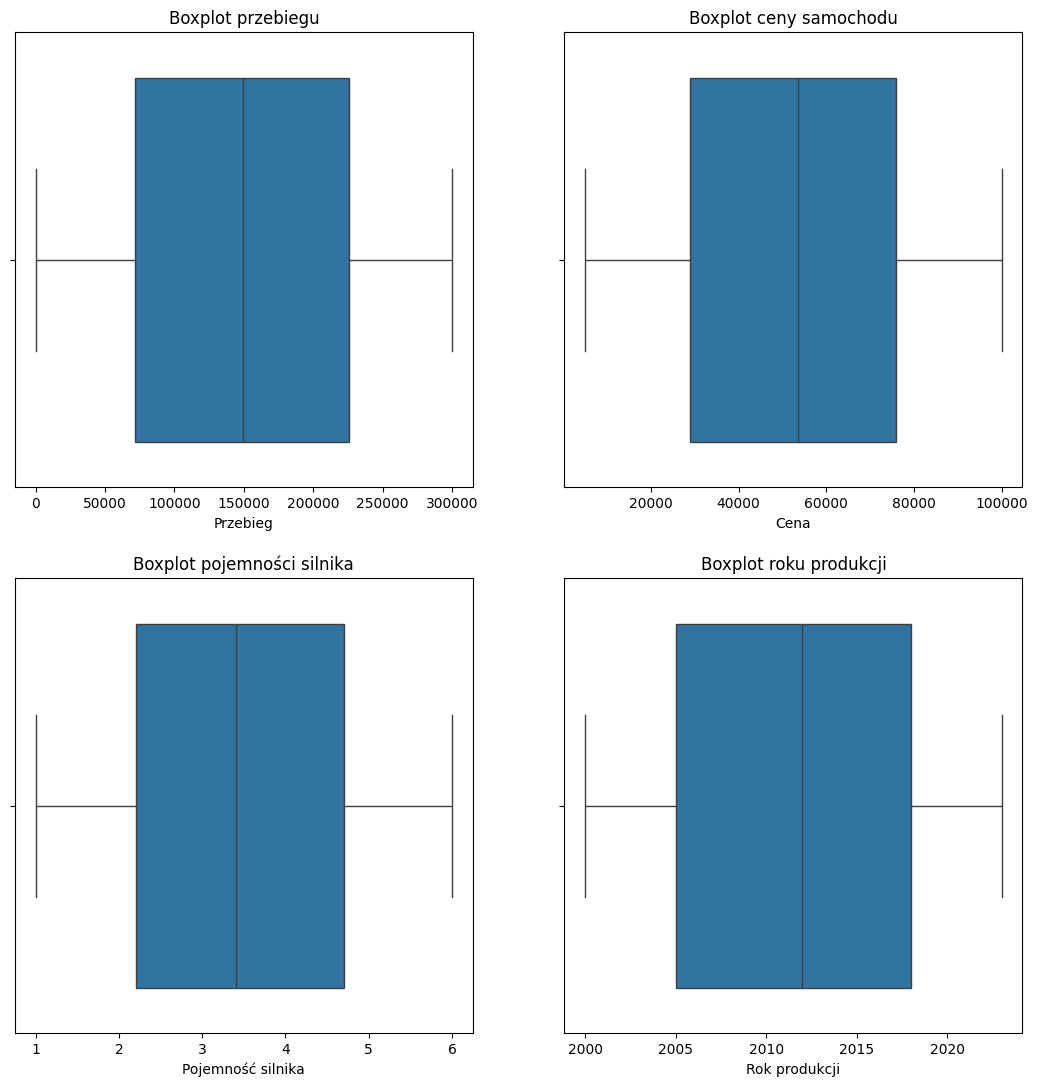

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))

sns.boxplot(x="Mileage", data=df, ax=axes[0,0])
axes[0,0].set_title("Boxplot przebiegu")
axes[0,0].set_xlabel("Przebieg")

sns.boxplot(x="Price", data=df, ax=axes[0,1])
axes[0,1].set_title("Boxplot ceny samochodu")
axes[0,1].set_xlabel("Cena")

sns.boxplot(x="Year", data=df, ax=axes[1,1])
axes[1,1].set_title("Boxplot roku produkcji")
axes[1,1].set_xlabel("Rok produkcji")

sns.boxplot(x="Engine Size", data=df, ax=axes[1,0])
axes[1,0].set_title("Boxplot pojemności silnika")
axes[1,0].set_xlabel("Pojemność silnika")

Na podstawie wykresów jak i df.describe nie widać żadnych outlierów. Wartości mieszczą się w dość rozsądnych przedzałach.


In [7]:
print("Wszystkie marki pojazdów znajdujące się w danych", df["Brand"].unique())
print("\nWszystkie modele aut znajdujące się w danych", df["Model"].unique())

Wszystkie marki pojazdów znajdujące się w danych ['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']

Wszystkie modele aut znajdujące się w danych ['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'GLA' 'A3' 'X5' 'C-Class' 'E-Class'
 'CR-V' 'Camry' 'Accord' 'GLC' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'RAV4' 'Focus']


Nie stwierdzono żadnych niezgodnych modeli lub marek, ani żadnych błędnie zapisanych nazw.

Feature engineering

In [8]:
df.nunique()

Brand              7
Year              24
Engine Size       51
Fuel Type          4
Transmission       2
Mileage         2490
Condition          3
Price           2499
Model             28
dtype: int64

Zamiana Transmission na dane 0/1. Gdzie 0 znaczy skrzynia manualna, 1 to automat (żeby w pracy przy danych np. modelach predykcyjnych można było przetrwarzać te dane).

In [9]:
print(df["Transmission"].unique())
df["Transmission"] = (df["Transmission"] == 'Automatic').astype(int)

['Manual' 'Automatic']


Podobnie sprawa odnosi się do Condition, 0 to Used, 1 to Like New, a 2 to New.

In [10]:
print(df["Condition"].unique())

df['Condition'] = np.where(df['Condition'] == 'New', 2, np.where(df['Condition'] == 'Like New', 1, 0))

['New' 'Used' 'Like New']


Z racji tego, że zmienne Fuel Type ma parę unikalnych wartości zastosowałam one hot encoding.

In [11]:
ohe_FT=pd.get_dummies(df["Fuel Type"], dtype=int)
df=pd.concat([df,ohe_FT], axis=1)
df.drop(columns="Fuel Type", inplace=True)

Jeśli chodzi o kolumny Brand i Model nieefektywnym byłoby stosować ohe (w Brand jest 7, a w Model jest 28 wartości uniklanych, czyli po ohe byłoby bardzo dużo kolumn). Do modelowania na ich podstawie trzeba by zamienić je na dane numeryczne, ale nie jestem pewna czego użyć, więc postanowiłam je zostawić, choć stanowią ważne dane do przewidywania ceny.

Wizualizacja relacji między zmiennymi

In [12]:
df.head()

,Brand,Year,Engine Size,Transmission,Mileage,Condition,Price,Model,Diesel,Electric,Hybrid,Petrol
0,Tesla,2016,2.3,0,114832,2,26613.92,Model X,0,0,0,1
1,BMW,2018,4.4,0,143190,0,14679.61,5 Series,0,1,0,0
2,Audi,2013,4.5,0,181601,2,44402.61,A4,0,1,0,0
3,Tesla,2011,4.1,1,68682,2,86374.33,Model Y,1,0,0,0
4,Ford,2009,2.6,0,223009,1,73577.10,Mustang,1,0,0,0


Text(0, 0.5, 'Średnia cena')

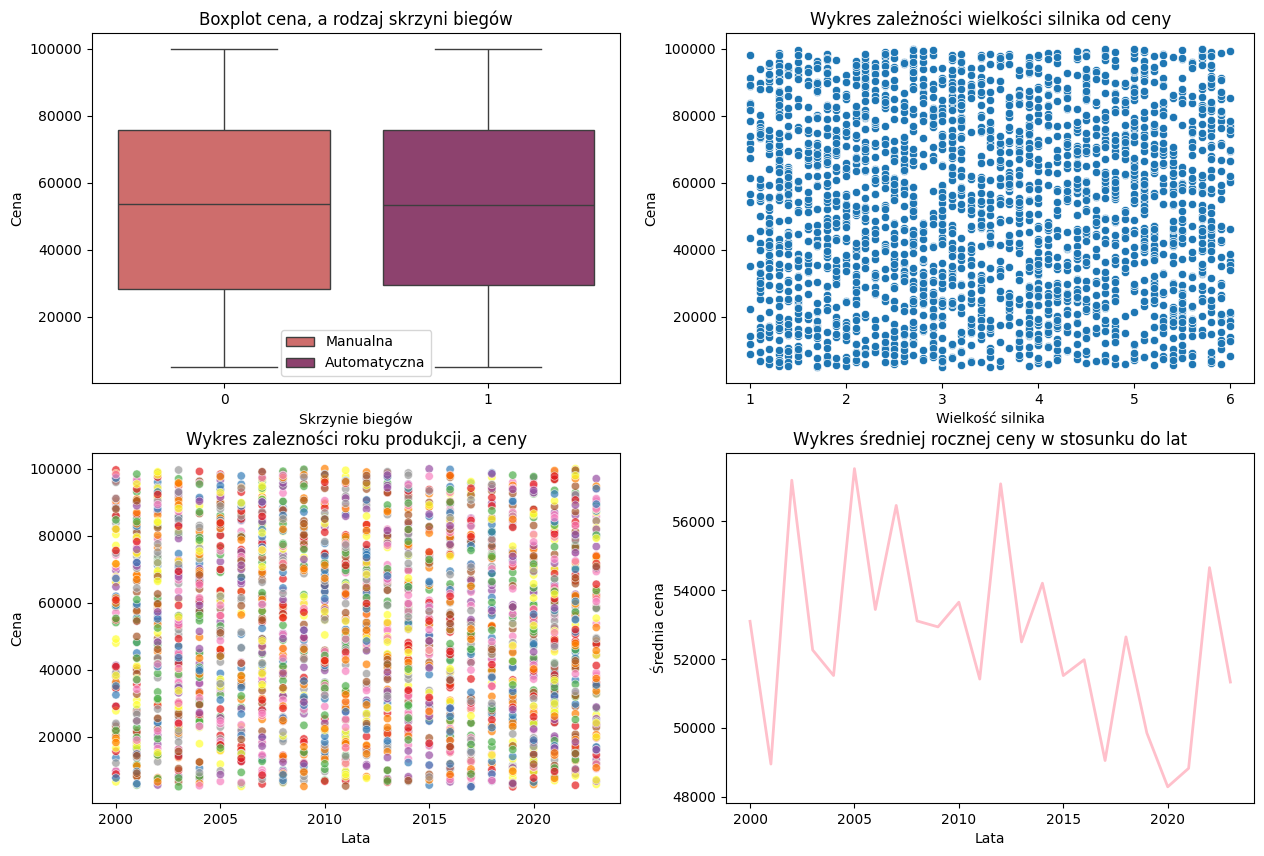

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x='Transmission', y='Price', data=df, palette="flare", hue='Transmission', ax=axes[0,0])
axes[0,0].set_title("Boxplot cena, a rodzaj skrzyni biegów")
axes[0,0].set_xlabel("Skrzynie biegów")
axes[0,0].set_ylabel("Cena")
axes[0,0].legend(labels=["Manualna", "Automatyczna"])

sns.scatterplot(x='Year', y='Price', palette="Set1", hue='Price', legend=False, data=df, alpha=0.7, ax=axes[1,0])
axes[1,0].set_title("Wykres zalezności roku produkcji, a ceny")
axes[1,0].set_xlabel("Lata")
axes[1,0].set_ylabel("Cena")

sns.scatterplot(x='Engine Size', y='Price', data=df, ax=axes[0,1])
axes[0,1].set_title("Wykres zależności wielkości silnika od ceny")
axes[0,1].set_xlabel("Wielkość silnika")
axes[0,1].set_ylabel("Cena")

Yearly_mean = df.groupby('Year')['Price'].mean()
axes[1,1].plot(Yearly_mean.index, Yearly_mean.values, linewidth=2,  color='pink')
axes[1,1].set_title("Wykres średniej rocznej ceny w stosunku do lat")
axes[1,1].set_xlabel("Lata")
axes[1,1].set_ylabel("Średnia cena")

Text(0.5, 1.0, 'Wykres korelacyjny dla zmiennych numerycznych')

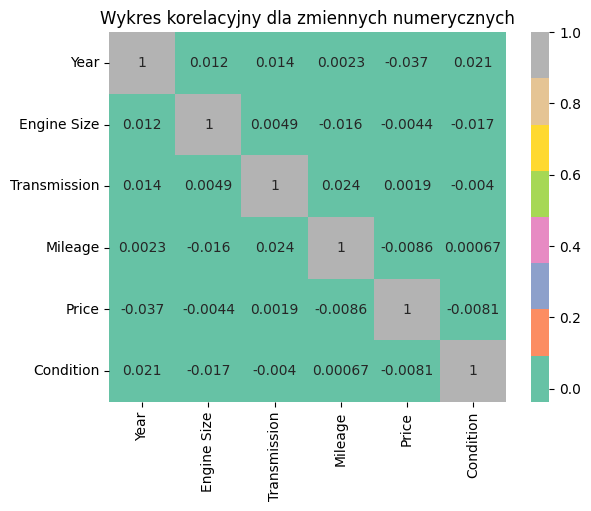

In [14]:
numeric=["Year", "Engine Size","Transmission","Mileage","Price","Condition"]
sns.heatmap(df[numeric].corr(), annot=True, cmap='Set2')
plt.title("Wykres korelacyjny dla zmiennych numerycznych")

Statystyki

In [15]:
Mean = df['Price'].mean().round(2)

MeanBrand=df.groupby('Brand')['Price'].mean()
MaxMeanBrand=MeanBrand.sort_values(ascending=False).head(1).index[0]

Correl=df['Mileage'].corr(df['Price']).round(6)

Mediana = df.groupby('Condition')['Price'].median().to_frame()

print(f"Średnia cena to {Mean}.")
print(f"Marka o najwyższej cenie średniej to {MaxMeanBrand}.")
print(f"Korelacja między przebiegiem, a ceną to {Correl}.")
print(f"Mediana ceny w zależności od stanu auta:\n {Mediana}\n gdzie 0 to używane,\n 1 to jak nowe,\n a 2 to nowe.")

Średnia cena to 52638.02.
Marka o najwyższej cenie średniej to BMW.
Korelacja między przebiegiem, a ceną to -0.008567.
Mediana ceny w zależności od stanu auta:
               Price
Condition          
0          52840.27
1          55069.13
2          52264.40
 gdzie 0 to używane,
 1 to jak nowe,
 a 2 to nowe.
